
- Doris Reiter: PRX-Q, PRR on SUPER

## Main Goals
- show that the 1 - 2 photon picture is also valid for the interaction with pulses (not only cavity modes)
- show, however, that this only works with a minimum number of photons in both modes (due to the free-space coupling -> parameter scans)
- "combine" input-output formalism with cumulant expansion

## Additional investigations
- multiple atoms -> convert more photons (stimualted emission?)
- convert photons continuously (into a cavity or between two cavity modes; gain fro stimulated emission?)

In [1]:
include("/home/christoph/MEGA2/JULIA_FUNCTIONS/QuantumInputOutput/src/QuantumInputOutput.jl")
# include("/home/christoph/MEGA2/JULIA_FUNCTIONS/2024_09__functions_traveling_pulse.jl")

using PyPlot
using OrdinaryDiffEq

cd(@__DIR__)
abstol = 1e-8
reltol = 1e-8;

In [2]:
# Hilberspace
hu1 = FockSpace(:u1)
hu2 = FockSpace(:u2)
hs1 = NLevelSpace(:atom,2)
hv1 = FockSpace(:v1)
hv2 = FockSpace(:v2)
h = tensor(hu1,hu2,hs1,hv1,hv2)

# Operators
au1 = Destroy(h,"a_{u1}",1)
au2 = Destroy(h,"a_{u2}",2)
s(i,j) = Transition(h,:s,i,j)
av1 = Destroy(h,"a_{v1}",4)
av2 = Destroy(h,"a_{v2}",5)

@rnumbers Δ0 Ω0 γ Δ1 Δ2 Δ 
@cnumbers α1 α2 σ1 σ2 τ1 τ2
gu1, gu2, gv1, gv2 = cnumbers("g_{u1} g_{u2} g_{v1} g_{v2}")

@syms t::Real;

# 1. Classical Drive

In [3]:
@register_symbolic Ω(t)
@register_symbolic Ω_c(t) # Ω0(t)' does not work! - complex

H_cl = -( Ω_c(t)*s(1,2) + Ω(t)*s(2,1) )

J_cl = [s(1,2)]
rates_cl = [γ]

ops_cl = [s(2,2), s(1,2)];

In [4]:
eqs_cl = meanfield(ops_cl, H_cl, J_cl; rates=rates_cl)

∂ₜ(⟨s22⟩) = (0 - 1im)*Main.Ω_c(t)*⟨s12⟩ - ⟨s22⟩*γ + (0 + 1im)*Main.Ω(t)*⟨s21⟩
∂ₜ(⟨s12⟩) = (0 + 1im)*Main.Ω(t) + (0 - 2im)*⟨s22⟩*Main.Ω(t) - 0.5⟨s12⟩*γ


In [5]:
@named sys_cl = ODESystem(eqs_cl);

In [6]:
# Parameter (in units of THz)
# T0 = -12; Tend = 12
dt = 1e-4
T0 = dt; Tend = 12*2
T = [T0:dt:Tend;]
ΔT = T[3] - T[2]

γ_ = 1e-2#3
Δ1_ = -2π*1.934
Δ2_ = -2π*4.634
α1_ = 22.65π
α2_ = 19.29π
σ1_ = 2.4
σ2_ = 3.04
τ1_ = 0.0 + 12
τ2_ = -0.73 +12
Δ0_ = 0

Ω1(t) = 0.5*1/(√(2π))*α1_/σ1_*exp(-(t-τ1_)^2/(2*σ1_^2))*exp(-1im*Δ1_*t)
Ω2(t) = 0.5*1/(√(2π))*α2_/σ2_*exp(-(t-τ2_)^2/(2*σ2_^2))*exp(-1im*Δ2_*t)
Ω(t) = Ω1(t) + Ω2(t)
Ω_c(t) = conj(Ω(t))

ps_cl = [γ , Δ1 , Δ2 , α1 , α2 , σ1 , σ2 , τ1 , τ2 ]
p0_cl = [γ_, Δ1_, Δ2_, α1_, α2_, σ1_, σ2_, τ1_, τ2_];

In [7]:
α1_

71.15707360380881

In [ ]:
u0_cl = zeros(ComplexF64, length(eqs_cl))
dict_u0_cl = merge(Dict(unknowns(sys_cl) .=> u0_cl), Dict(ps_cl .=> p0_cl))
prob_cl = ODEProblem(sys_cl,dict_u0_cl,(T0, Tend))

sol_cl = solve(prob_cl,RK4(); abstol, reltol)

t_cl = sol_cl.t
s22_cl = real.(sol_cl[s(2,2)]);

In [ ]:
close("population")
figure("population")
plot(t_cl, s22_cl, label="classical")
xlabel("time")
ylabel("population")
grid(true)
legend()
tight_layout()
display(gcf());

# 2. Input-Output (no interaction picture)

In [10]:
G_u2 = SLH(1, gu2*au2, 0) # input cavity 2
G_u1 = SLH(1, gu1*au1, 0) # input cavity 1
G_2lvl = SLH(1, √(γ)*s(1,2), Δ*s(2,2)) # 2-level system
G_v1 = SLH(1, gv1*av1, 0) # output cavity 1
G_v2 = SLH(1, gv2*av2, 0) # output cavity 2

G_cas = ▷(G_u2, G_u1, G_2lvl, G_v1, G_v2);

In [11]:
H = get_hamiltonian(G_cas)

((0.0 - 0.5im)*var"g_{u2}"*conj(var"g_{v2}")*(a_{u2}*a_{v2}′)+(0.0 + 0.5im)*var"g_{v1}"*sqrt(γ)*(s21*a_{v1})+(0.0 - 0.5im)*conj(var"g_{v2}")*sqrt(γ)*(s12*a_{v2}′)+(0.0 + 0.5im)*var"g_{v2}"*sqrt(γ)*(s21*a_{v2})+(0.0 + 0.5im)*var"g_{v2}"*conj(var"g_{v1}")*(a_{v1}′*a_{v2})+(0.0 + 0.5im)*var"g_{v2}"*conj(var"g_{u2}")*(a_{u2}′*a_{v2})+(0.0 - 0.5im)*var"g_{u2}"*conj(var"g_{u1}")*(a_{u1}′*a_{u2})+Δ*(s22)+(0.0 - 0.5im)*var"g_{u1}"*sqrt(γ)*(a_{u1}*s21)+(0.0 + 0.5im)*var"g_{u1}"*conj(var"g_{u2}")*(a_{u1}*a_{u2}′)+(0.0 - 0.5im)*var"g_{u2}"*conj(var"g_{v1}")*(a_{u2}*a_{v1}′)+(0.0 + 0.5im)*var"g_{v1}"*conj(var"g_{u1}")*(a_{u1}′*a_{v1})+(0.0 + 0.5im)*conj(var"g_{u1}")*sqrt(γ)*(a_{u1}′*s12)+(0.0 - 0.5im)*conj(var"g_{v1}")*sqrt(γ)*(s12*a_{v1}′)+(0.0 + 0.5im)*var"g_{v1}"*conj(var"g_{u2}")*(a_{u2}′*a_{v1})+(0.0 + 0.5im)*conj(var"g_{u2}")*sqrt(γ)*(a_{u2}′*s12)+(0.0 + 0.5im)*var"g_{v2}"*conj(var"g_{u1}")*(a_{u1}′*a_{v2})+(0.0 - 0.5im)*var"g_{u1}"*conj(var"g_{v2}")*(a_{u1}*a_{v2}′)+(0.0 - 0.5im)*var"g_{u2}

In [12]:
L = get_lindblad(G_cas)[1] # only one Lindblad in this example

(sqrt(γ)*(s12)+var"g_{v1}"*(a_{v1})+var"g_{v2}"*(a_{v2})+var"g_{u1}"*(a_{u1})+var"g_{u2}"*(a_{u2}))

In [13]:
Ld = adjoint(L)

(sqrt(γ)*(s21)+conj(var"g_{v1}")*(a_{v1}′)+conj(var"g_{v2}")*(a_{v2}′)+conj(var"g_{u1}")*(a_{u1}′)+conj(var"g_{u2}")*(a_{u2}′))

In [14]:
@register_symbolic gu1_t(t) 
@register_symbolic gu2_t(t)
@register_symbolic gv1_t(t) 
@register_symbolic gv2_t(t)
# complex conjugated
@register_symbolic gu1_c_t(t) 
@register_symbolic gu2_c_t(t)
@register_symbolic gv1_c_t(t) 
@register_symbolic gv2_c_t(t)

g_ls = [gu1, gu2, gv1, gv2]
gt_ls = [gu1_t(t), gu2_t(t), gv1_t(t), gv2_t(t)]
gct_ls = [gu1_c_t(t), gu2_c_t(t), gv1_c_t(t), gv2_c_t(t)]

dict_p_t = Dict([g_ls; conj.(g_ls)] .=> [gt_ls; gct_ls]);

In [15]:
H_t = substitute(H, dict_p_t);
L_t = substitute(L, dict_p_t);
Ld_t = substitute(Ld, dict_p_t);

In [16]:
u1(t_) = 1/(√(σ1_)*π^(1/4)) * exp( -(t_ - τ1_)^2 / (2*σ1_^2) ) * exp(-1im*Δ1_*t_)
u2(t_) = 1/(√(σ2_)*π^(1/4)) * exp( -(t_ - τ2_)^2 / (2*σ2_^2) ) * exp(-1im*Δ2_*t_)

gu1_t_ = u_to_gu_Gauss(u1, τ1_, σ1_)
gu1_t(t) = gu1_t_(t)
gv1_t_ = v_to_gv_Gauss(u1, τ1_, σ1_)
gv1_t(t) = gv1_t_(t)
;

gu1_c_t(t) = conj(gu1_t(t))
gv1_c_t(t) = conj(gv1_t(t))
;

In [17]:
u_fcts = [u1, u2]
gu2_ = u_to_gu(u_eff(u_fcts, T, 2),T)
gu2_t(t) = gu2_(t)
gu2_c_t(t) = conj(gu2_t(t));

v_fcts = [u1, u2] # output = input mode
gv2_ = v_to_gv(v_eff(v_fcts, T, 2),T)
gv2_t(t) = gv2_(t)
gv2_c_t(t) = conj(gv2_t(t));

In [18]:
order = 1
ops = ( order == 1 ? [au1, au2, s(2,2), s(2,1), av1, av2] : 
    [au1, au2, s(2,2), s(2,1), av1, av2, av1'av1, av2'av2]);

In [19]:
# TODO: obtain eqs first and then substitute time-dependent couplings

In [20]:
eqs = meanfield(ops, H_t, [L_t]; Jdagger=[Ld_t], order=order)

∂ₜ(⟨a_{u1}⟩) = -0.5⟨a_{u1}⟩*Main.gu1_t(t)*Main.gu1_c_t(t) + -⟨a_{u2}⟩*Main.gu2_t(t)*Main.gu1_c_t(t)
∂ₜ(⟨a_{u2}⟩) = -0.5⟨a_{u2}⟩*Main.gu2_t(t)*Main.gu2_c_t(t)
∂ₜ(⟨s22⟩) = -⟨s22⟩*(sqrt(γ)^2) + -⟨s21⟩*⟨a_{u1}⟩*Main.gu1_t(t)*sqrt(γ) + -⟨s21⟩*⟨a_{u2}⟩*Main.gu2_t(t)*sqrt(γ) + -⟨a_{u1}′⟩*⟨s12⟩*sqrt(γ)*Main.gu1_c_t(t) + -Main.gu2_c_t(t)*⟨s12⟩*sqrt(γ)*⟨a_{u2}′⟩
∂ₜ(⟨s21⟩) = (0 + 1im)*⟨s21⟩*Δ - 0.5⟨s21⟩*(sqrt(γ)^2) + -⟨a_{u1}′⟩*sqrt(γ)*Main.gu1_c_t(t) + -Main.gu2_c_t(t)*sqrt(γ)*⟨a_{u2}′⟩ + (2.0 - 0.0im)⟨a_{u1}′⟩*⟨s22⟩*sqrt(γ)*Main.gu1_c_t(t) + (2.0 - 0.0im)⟨s22⟩*Main.gu2_c_t(t)*sqrt(γ)*⟨a_{u2}′⟩
∂ₜ(⟨a_{v1}⟩) = -⟨a_{u1}⟩*Main.gu1_t(t)*Main.gv1_c_t(t) + -⟨a_{u2}⟩*Main.gu2_t(t)*Main.gv1_c_t(t) - 0.5⟨a_{v1}⟩*Main.gv1_t(t)*Main.gv1_c_t(t) + -⟨s12⟩*Main.gv1_c_t(t)*sqrt(γ)
∂ₜ(⟨a_{v2}⟩) = -⟨a_{u1}⟩*Main.gu1_t(t)*Main.gv2_c_t(t) + -⟨a_{u2}⟩*Main.gu2_t(t)*Main.gv2_c_t(t) - 0.5Main.gv2_t(t)*⟨a_{v2}⟩*Main.gv2_c_t(t) + -⟨a_{v1}⟩*Main.gv2_c_t(t)*Main.gv1_t(t) + -Main.gv2_c_t(t)*⟨s12⟩*sqrt(γ)


In [21]:
complete!(eqs)
length(eqs)

6

In [22]:
α1_io = α1_ / (2*√(2)*π^(1/4)*√(σ1_*γ_)) # coherent state amplitude field 1
α2_io = α2_ / (2*√(2)*π^(1/4)*√(σ2_*γ_))

92.30236883983622

In [23]:
# needed to numerically define a coherent state with a large α
poisson(k,λ) = exp(k*log(λ) - λ - loggamma(k+1) )
function QuantumOpticsBase.coherentstate!(ket::Ket, b::FockBasis, alpha::Number)
    C = eltype(ket)
    T = real(C)
    alpha = C(alpha)
    data = ket.data

    # Compute coefficient up to offset
    λ = abs2(alpha)
    ϕ = angle(alpha) 
    offset = b.offset
    @inbounds for n=offset:b.N
        i=n-offset+1
        data[i] = sqrt(poisson(n,λ))*exp(1im*ϕ*n)
    end

    return ket
end

rd(x) = round(Int,x)
function ψ0_u1u2s1v1v2(α1, α2, eqs)
    bu1 = FockBasis(rd(α1^2 + 20α1), rd(α1^2 - 20α1))
    bu2 = FockBasis(rd(α2^2 + 20α2), rd(α2^2 - 20α2))
    bs1 = NLevelBasis(2)
    bv1 = FockBasis(1)
    bv2 = FockBasis(1)
    b = tensor([bu1, bu2, bs1, bv1, bv2]...)

    ψu1 = coherentstate(bu1, α1)
    ψu2 = coherentstate(bu2, α2)
    ψs1 = nlevelstate(bs1,1)
    ψv1 = fockstate(bv1,0)
    ψv2 = fockstate(bv2,0)
    ψ0 = LazyKet(b, (ψu1, ψu2, ψs1, ψv1, ψv2))
    return initial_values(eqs, ψ0)
end

u0 = ψ0_u1u2s1v1v2(α1_io, α2_io, eqs)
u0[1]

121.97757541817745 + 0.0im

In [24]:
@named sys = ODESystem(eqs);

In [25]:
ps = [γ , Δ0 , Δ]
p0 = [γ_, Δ0_, 0]
dict_u0 = merge(Dict(unknowns(sys) .=> u0), Dict(ps .=> p0))
prob = ODEProblem(sys, dict_u0, (T0,Tend));

In [26]:
sol = solve(prob, Tsit5(); abstol, reltol);

In [27]:
t_ = sol.t
s22 = real(sol[s(2,2)])
nu1 = ( order == 1 ? abs2.(sol[au1]) : real.(sol[au1'au1]) )
nu2 = ( order == 1 ? abs2.(sol[au2]) : real.(sol[au2'au2]) )
nv1 = ( order == 1 ? abs2.(sol[av1]) : real.(sol[av1'av1]) )
nv2 = ( order == 1 ? abs2.(sol[av2]) : real.(sol[av2'av2]) );

In [28]:
println("Δn1 = $(nu1[1] - nv1[end])")
println("Δn2 = $(nu2[1] - nv2[end])")

Δn1 = 2.0062796043821436
Δn2 = -0.992872948270815


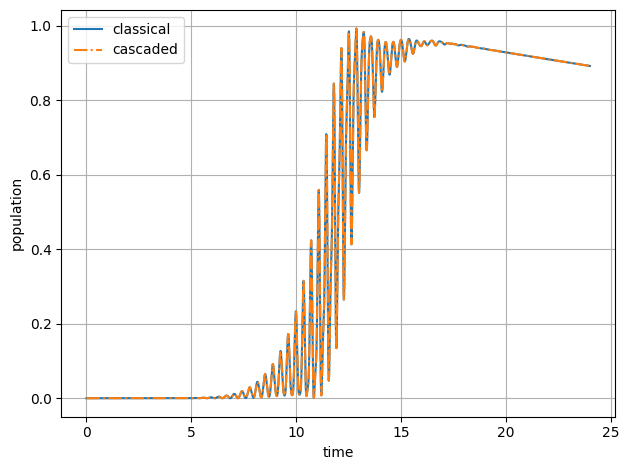

In [29]:
figure("population")
plot(t_, s22, ls="-.", label="cascaded")
legend()
display(gcf())
savefig("figures/06-1_SUPER-exc_popu.png")

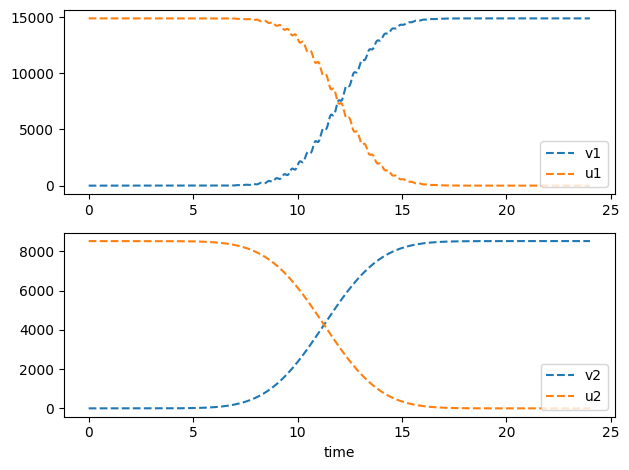

In [30]:
close("mode 1"); 
figure("mode 1")
subplot(211)
plot(t_, nv1, label="v1", ls="--")
plot(t_, nu1, label="u1", ls="--")
legend(loc="lower right")
#
subplot(212)
plot(t_, nv2, label="v2", ls="--")
plot(t_, nu2, label="u2", ls="--")
legend(loc="lower right")
xlabel("time")
tight_layout()
display(gcf())
savefig("figures/06-1_SUPER-exc_mode_1and2.png");

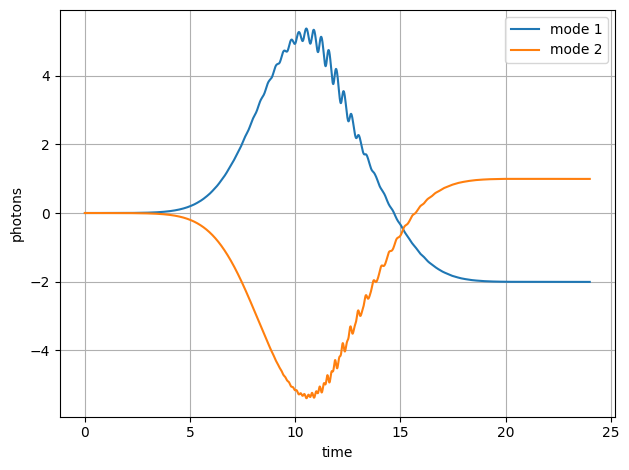

In [31]:
close("mode photon loss/gain");
figure("mode photon loss/gain")
plot(t_, nu1 .+ nv1 .- nu1[1], label="mode 1")
plot(t_, nu2 .+ nv2 .- nu2[1], label="mode 2")
ylabel("photons")
xlabel("time")
grid()
legend()
tight_layout()
display(gcf())
savefig("figures/06-1_SUPER-exc_mode_1and2_loss-gain.png");